# Model Fitting and Evaluation

The main goal of this notebook is to fit the proposed models to the available data and evaluate its performance and validity.

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import sys

PROJECT_ROOT = Path.cwd().parent
DATA_PATH = PROJECT_ROOT / "data" / "processed" / "tumorgrowth-processed.csv"

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.models.tumor_model_basic import simulate_tumor_basic
from src.models.tumor_model_advanced import simulate_tumor_advanced

from src.models.fit_model_basic import fit_model_basic, loss_function
from src.models.fit_model_advanced import fit_model_advanced

In [2]:
# 1. Load data
data = pd.read_csv(DATA_PATH)

data.head()

,Grp,Group,ID,Day,Size,Baseline,RTV
0,1.CTR,1,101,0,41.8,41.8,1.000000
1,1.CTR,1,101,3,85.0,41.8,2.033493
2,1.CTR,1,101,4,114.0,41.8,2.727273
3,1.CTR,1,101,5,162.3,41.8,3.882775
4,1.CTR,1,101,6,178.3,41.8,4.265550


## Basic Model

Firstly the basic mechanistic model will be fitted (it does not contemplate acquired resistance to treatment). This model will serve as a benchmark for the advanced one (which does contemplate acquired resistance), and it will be assessed whether the addition of the extra parameters improves significantly the performance of the model.

In [4]:
seed = 23 ; maxiter = 100 ; popsize = 10

results_df = fit_model_basic(data,
                             seed,
                             maxiter,
                             popsize)

CPU times: total: 0 ns
Wall time: 0 ns


C:\Users\usuari\Desktop\Projectes\tumor-modelling\src\models\fit_model_basic.py:11: RuntimeWarning: divide by zero encountered in log
  return float(np.mean((np.log(T_obs) - np.log(T_pred)) ** 2))


In [5]:
results_df.head(10)

,Group,r,K,al,MSE
0,1,0.311208,4002.503633,0.000000,0.290477
1,2,0.311208,4002.503633,0.119995,0.290477
2,3,0.311208,4002.503633,0.075330,0.290477
3,4,0.311208,4002.503633,0.127209,0.290477


In order to get a grasp of the model behavior in the following three instances of prediction vs. observed per treatment group will be plotted in the following

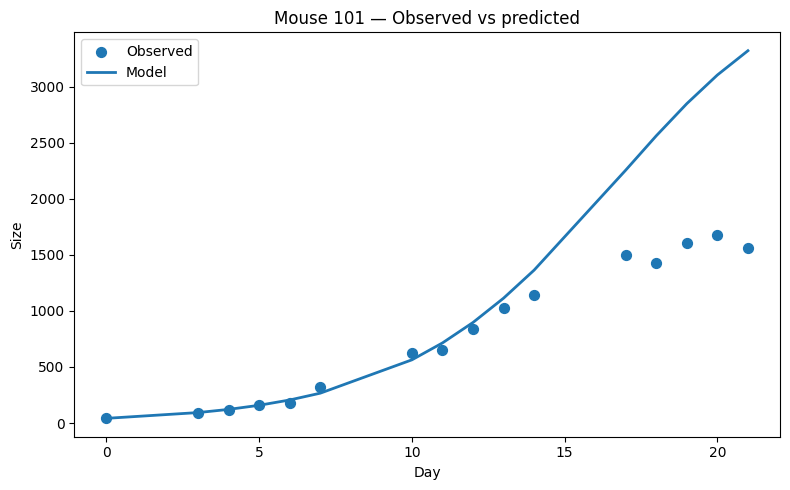

In [6]:
# Petita prova
mouse_id = data["ID"].unique()[0]

mouse_data = data[data["ID"] == mouse_id]

T_obs = mouse_data["Size"].to_numpy()
times = mouse_data["Day"].to_numpy()
T0 = T_obs[0]

grp = mouse_data["Group"].iloc[0]

r = results_df["r"].iloc[0]
K = results_df["K"].iloc[0]
al = results_df.loc[
    results_df["Group"] == grp, "al"
].iloc[0]

D = grp > 1

# Simulate
sim_df = simulate_tumor_basic(
    T0=T0,
    r=r,
    K=K,
    al=al,
    times=times,
    D=D
)

# Plot
plt.figure(figsize=(8, 5))

plt.scatter(
    times,
    T_obs,
    label="Observed",
    s=50
)

plt.plot(
    sim_df["Day"],
    sim_df["Size"],
    label="Model",
    linewidth=2
)

plt.xlabel("Day")
plt.ylabel("Size")
plt.title(f"Mouse {mouse_id} — Observed vs predicted")
plt.legend()
plt.tight_layout()
plt.show()